# Percolation Analysis

Spatial connectivity percolation applied to mound centroids. A distance threshold *r* is swept from fine to coarse; at each step, mounds within distance *r* are connected as graph edges and connected components are extracted. The percolation threshold *r*_c marks the critical scale at which a giant connected component first emerges and spans the parcel / the point at which the mound distribution transitions from fragmented to globally connected.

In [13]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

print('imports done')

imports done


## 1. Load data

In [14]:
features = gpd.read_file("/Users/amber/Documents/M Thesis/Data/QGIS/isaura_features.gpkg")
parcel   = gpd.read_file("/Users/amber/Documents/M Thesis/Data/QGIS/08_isaura_extent_parcels.gpkg")
mounds   = features[features['type'] == 'mound'].copy()

print(f"Mound features: {len(mounds)}")
print(f"CRS: {mounds.crs}")

Mound features: 2671
CRS: EPSG:32644


## 2. Extract centroids

In [15]:
centroids = mounds.geometry.centroid
x = centroids.x.values
y = centroids.y.values
coords = np.column_stack([x, y])
N = len(coords)

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
parcel_diag  = np.hypot(x_max - x_min, y_max - y_min)

print(f"n = {N}")
print(f"X range: {x_min:.0f} - {x_max:.0f} m")
print(f"Y range: {y_min:.0f} - {y_max:.0f} m")
print(f"Parcel diagonal: {parcel_diag:.0f} m")

n = 2671
X range: 364 - 21385 m
Y range: -5 - 15656 m
Parcel diagonal: 26213 m


---
## 3. Define r sweep

The sweep range is anchored to the mean nearest-neighbour distance (NND). The lower bound starts below the mean NND (sub-connectivity regime); the upper bound is set to ~3,000 m, well beyond the scale at which most clusters are fully merged.

In [16]:
tree = cKDTree(coords)
d2, _ = tree.query(coords, k=2)
mean_nnd = d2[:, 1].mean()
median_nnd = np.median(d2[:, 1])

print(f"Mean NND:   {mean_nnd:.1f} m")
print(f"Median NND: {median_nnd:.1f} m")

# Logarithmically spaced sweep: 50 m -> 3000 m, 200 steps
r_values = np.logspace(np.log10(50), np.log10(3000), 200)
print(f"\nSweep range: {r_values[0]:.0f} m - {r_values[-1]:.0f} m ({len(r_values)} steps)")

Mean NND:   120.1 m
Median NND: 103.3 m

Sweep range: 50 m - 3000 m (200 steps)


---
## 4. Percolation sweep

At each threshold *r*, pairs of mounds within distance *r* are connected as graph edges using a KD-tree query. Connected components are then extracted from the resulting graph. Tracked metrics:

- **S** - largest component fraction (giant component size / N)
- **n_comp** - total number of connected components
- **S2** - average non-giant component size (susceptibility proxy)
- **spanning** - whether the largest component spans both parcel extents in X and Y

In [17]:
S_values      = np.zeros(len(r_values))   # giant component fraction
n_comp_values = np.zeros(len(r_values))   # number of components
S2_values     = np.zeros(len(r_values))   # mean non-giant component size
spanning      = np.zeros(len(r_values), dtype=bool)  # spanning criterion

for i, r in enumerate(r_values):
    pairs = tree.query_pairs(r)
    G     = nx.Graph()
    G.add_nodes_from(range(N))
    G.add_edges_from(pairs)

    comps        = list(nx.connected_components(G))
    comp_sizes   = np.array([len(c) for c in comps])
    giant_idx    = np.argmax(comp_sizes)
    giant_nodes  = np.array(list(comps[giant_idx]))
    giant_size   = comp_sizes[giant_idx]

    S_values[i]      = giant_size / N
    n_comp_values[i] = len(comps)

    non_giant = comp_sizes[comp_sizes != giant_size]
    S2_values[i] = non_giant.mean() if len(non_giant) > 0 else 0.0

    gx = coords[giant_nodes, 0]
    gy = coords[giant_nodes, 1]
    spanning[i] = (
        (gx.min() <= x_min + 0.05*(x_max - x_min)) and
        (gx.max() >= x_max - 0.05*(x_max - x_min)) and
        (gy.min() <= y_min + 0.05*(y_max - y_min)) and
        (gy.max() >= y_max - 0.05*(y_max - y_min))
    )

print("Sweep complete.")
print(f"First spanning r: {r_values[spanning][0]:.0f} m" if spanning.any() else "No spanning component found.")

Sweep complete.
First spanning r: 1117 m


---
## 5. Percolation threshold r_c

Two complementary estimates of the critical threshold:
1. **Maximum susceptibility** - r at the peak of d(S)/d(r), where the giant component grows fastest (standard percolation theory estimate).
2. **First-spanning r** - smallest r at which the giant component spans the full parcel extent (empirical connectivity criterion).

In [18]:
# Smooth S for derivative
S_smooth = savgol_filter(S_values, window_length=11, polyorder=3)
dS_dr    = np.gradient(S_smooth, r_values)

# Susceptibility peak (max growth rate)
rc_deriv_idx = np.argmax(dS_dr)
rc_deriv     = r_values[rc_deriv_idx]

# First-spanning r
if spanning.any():
    rc_span = r_values[np.argmax(spanning)]
else:
    rc_span = np.nan

print(f"r_c (max dS/dr):      {rc_deriv:.1f} m")
print(f"r_c (first spanning): {rc_span:.1f} m" if not np.isnan(rc_span) else "r_c (first spanning): not reached")
print(f"\nS at rc_deriv:        {S_values[rc_deriv_idx]:.3f}")
print(f"Components at rc_deriv: {n_comp_values[rc_deriv_idx]:.0f}")

r_c (max dS/dr):      325.2 m
r_c (first spanning): 1117.4 m

S at rc_deriv:        0.752
Components at rc_deriv: 127


---
## 6. Percolation curve

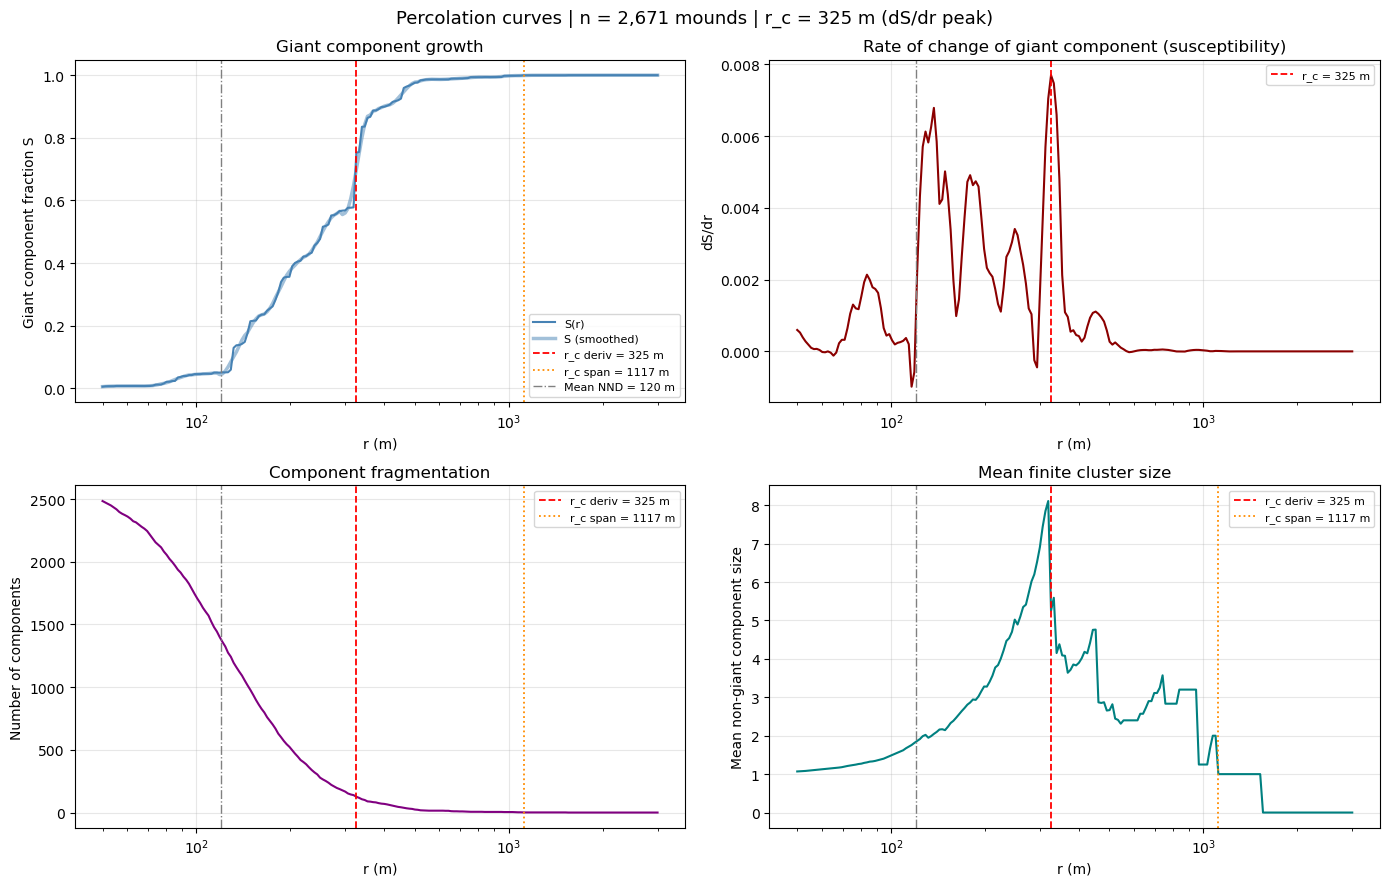

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Panel 1: Giant component fraction S
ax = axes[0, 0]
ax.semilogx(r_values, S_values, color='steelblue', linewidth=1.5, label='S(r)')
ax.semilogx(r_values, S_smooth, color='steelblue', linewidth=2.5, alpha=0.5, label='S (smoothed)')
ax.axvline(rc_deriv, color='red',    linestyle='--', linewidth=1.3, label=f'r_c deriv = {rc_deriv:.0f} m')
if not np.isnan(rc_span):
    ax.axvline(rc_span, color='darkorange', linestyle=':', linewidth=1.3, label=f'r_c span = {rc_span:.0f} m')
ax.axvline(mean_nnd, color='grey', linestyle='-.', linewidth=1, label=f'Mean NND = {mean_nnd:.0f} m')
ax.set_xlabel('r (m)')
ax.set_ylabel('Giant component fraction S')
ax.set_title('Giant component growth')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: dS/dr (susceptibility proxy)
ax = axes[0, 1]
ax.semilogx(r_values, dS_dr, color='darkred', linewidth=1.5)
ax.axvline(rc_deriv, color='red', linestyle='--', linewidth=1.3, label=f'r_c = {rc_deriv:.0f} m')
ax.axvline(mean_nnd, color='grey', linestyle='-.', linewidth=1)
ax.set_xlabel('r (m)')
ax.set_ylabel('dS/dr')
ax.set_title('Rate of change of giant component (susceptibility)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Number of components
ax = axes[1, 0]
ax.semilogx(r_values, n_comp_values, color='purple', linewidth=1.5)
ax.axvline(rc_deriv, color='red',    linestyle='--', linewidth=1.3, label=f'r_c deriv = {rc_deriv:.0f} m')
if not np.isnan(rc_span):
    ax.axvline(rc_span, color='darkorange', linestyle=':', linewidth=1.3, label=f'r_c span = {rc_span:.0f} m')
ax.axvline(mean_nnd, color='grey', linestyle='-.', linewidth=1)
ax.set_xlabel('r (m)')
ax.set_ylabel('Number of components')
ax.set_title('Component fragmentation')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Mean non-giant component size
ax = axes[1, 1]
ax.semilogx(r_values, S2_values, color='teal', linewidth=1.5)
ax.axvline(rc_deriv, color='red',    linestyle='--', linewidth=1.3, label=f'r_c deriv = {rc_deriv:.0f} m')
if not np.isnan(rc_span):
    ax.axvline(rc_span, color='darkorange', linestyle=':', linewidth=1.3, label=f'r_c span = {rc_span:.0f} m')
ax.axvline(mean_nnd, color='grey', linestyle='-.', linewidth=1)
ax.set_xlabel('r (m)')
ax.set_ylabel('Mean non-giant component size')
ax.set_title('Mean finite cluster size')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle(f'Percolation curves | n = {N:,} mounds | r_c = {rc_deriv:.0f} m (dS/dr peak)', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/percolation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Giant component map at r_c

At the critical threshold r_c, mounds within r_c of each other are connected as graph edges. The giant component (red) is the single largest connected subgraph. Grey points belong to smaller, isolated components that have not yet merged into the giant.

- The red mounds form a spatially coherent network at r_c: they are linked to each other (directly or via chains of neighbours) within the critical distance. This does not mean every red mound is within r_c of every other red mound - it means there is a path of step-wise connections between them. The giant component is the largest such continuously connected structure.
- r_c therefore marks the minimum interaction distance at which the mound distribution transitions from fragmented to a single dominant connected structure. It can be interpreted as a characteristic spacing threshold for the settlement network: below this distance, the landscape is patchy; above it, the network is effectively contiguous.

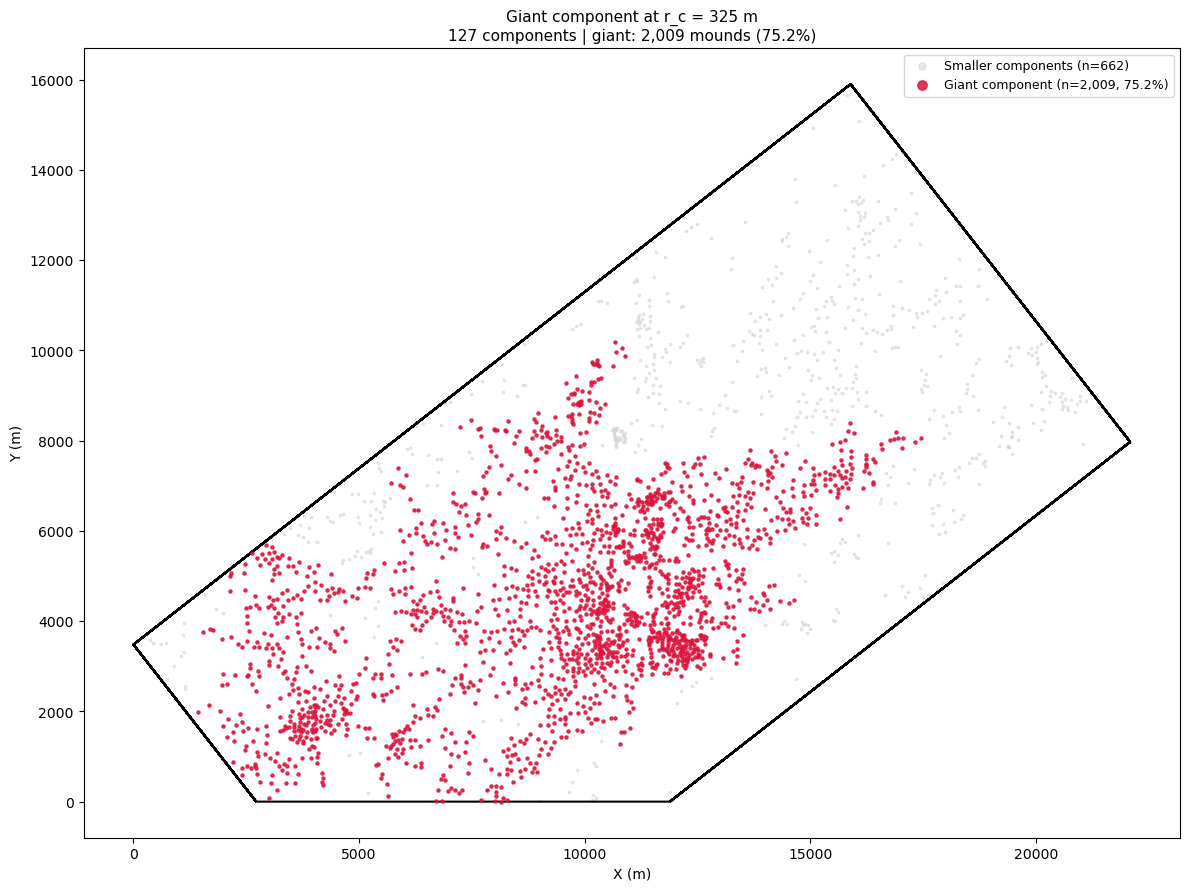

Saved: percolation_map_rc.png


In [20]:
def get_components_at_r(r):
    pairs = tree.query_pairs(r)
    G     = nx.Graph()
    G.add_nodes_from(range(N))
    G.add_edges_from(pairs)
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    return comps, G

comps_rc, G_rc = get_components_at_r(rc_deriv)
giant_nodes_rc = np.array(list(comps_rc[0]))
other_nodes_rc = np.array([n for c in comps_rc[1:] for n in c])

fig, ax = plt.subplots(figsize=(12, 10))

if len(other_nodes_rc) > 0:
    ax.scatter(coords[other_nodes_rc, 0], coords[other_nodes_rc, 1],
               s=3, c='lightgrey', alpha=0.5, zorder=2, label=f'Smaller components (n={len(other_nodes_rc):,})')

ax.scatter(coords[giant_nodes_rc, 0], coords[giant_nodes_rc, 1],
           s=5, c='crimson', alpha=0.85, zorder=3,
           label=f'Giant component (n={len(giant_nodes_rc):,}, {100*len(giant_nodes_rc)/N:.1f}%)')

parcel.boundary.plot(ax=ax, color='black', linewidth=1.5)
ax.set_title(
    f'Giant component at r_c = {rc_deriv:.0f} m\n'
    f'{len(comps_rc):,} components | giant: {len(giant_nodes_rc):,} mounds ({100*len(giant_nodes_rc)/N:.1f}%)',
    fontsize=11
)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9, markerscale=3)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/percolation_map_rc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: percolation_map_rc.png')

---
## 8. Multi-scale comparison

**Binary:** giant component (red) vs. rest (grey) at four r values. Shows how much of the network the giant absorbs at each scale.

**Coalescence map:** each mound is coloured by the first threshold at which it joins the giant component. Mounds that are already part of the densest core join at the sub-critical stage (dark blue); mounds absorbed at the critical transition are green; later joiners are orange and red; mounds that never enter the giant component within the sweep are grey. This reveals the spatial order of network integration i.e. which parts of the landscape were structurally central and which were peripheral.

In [21]:
r_compare = [
    r_values[np.searchsorted(r_values, rc_deriv * 0.40)],   # sub-critical
    rc_deriv,                                                 # critical
    r_values[np.searchsorted(r_values, rc_deriv * 2.0, side='right') - 1],   # supra-critical
    r_values[np.searchsorted(r_values, rc_deriv * 4.0, side='right') - 1],   # merged
]
r_compare      = [min(r, r_values[-1]) for r in r_compare]
labels_compare = ['Sub-critical', 'Critical (r_c)', 'Supra-critical', 'Merged']

all_comps = {r: get_components_at_r(r)[0] for r in r_compare}
print('r values:', [f'{r:.0f} m' for r in r_compare])

r values: ['132 m', '325 m', '641 m', '1291 m']


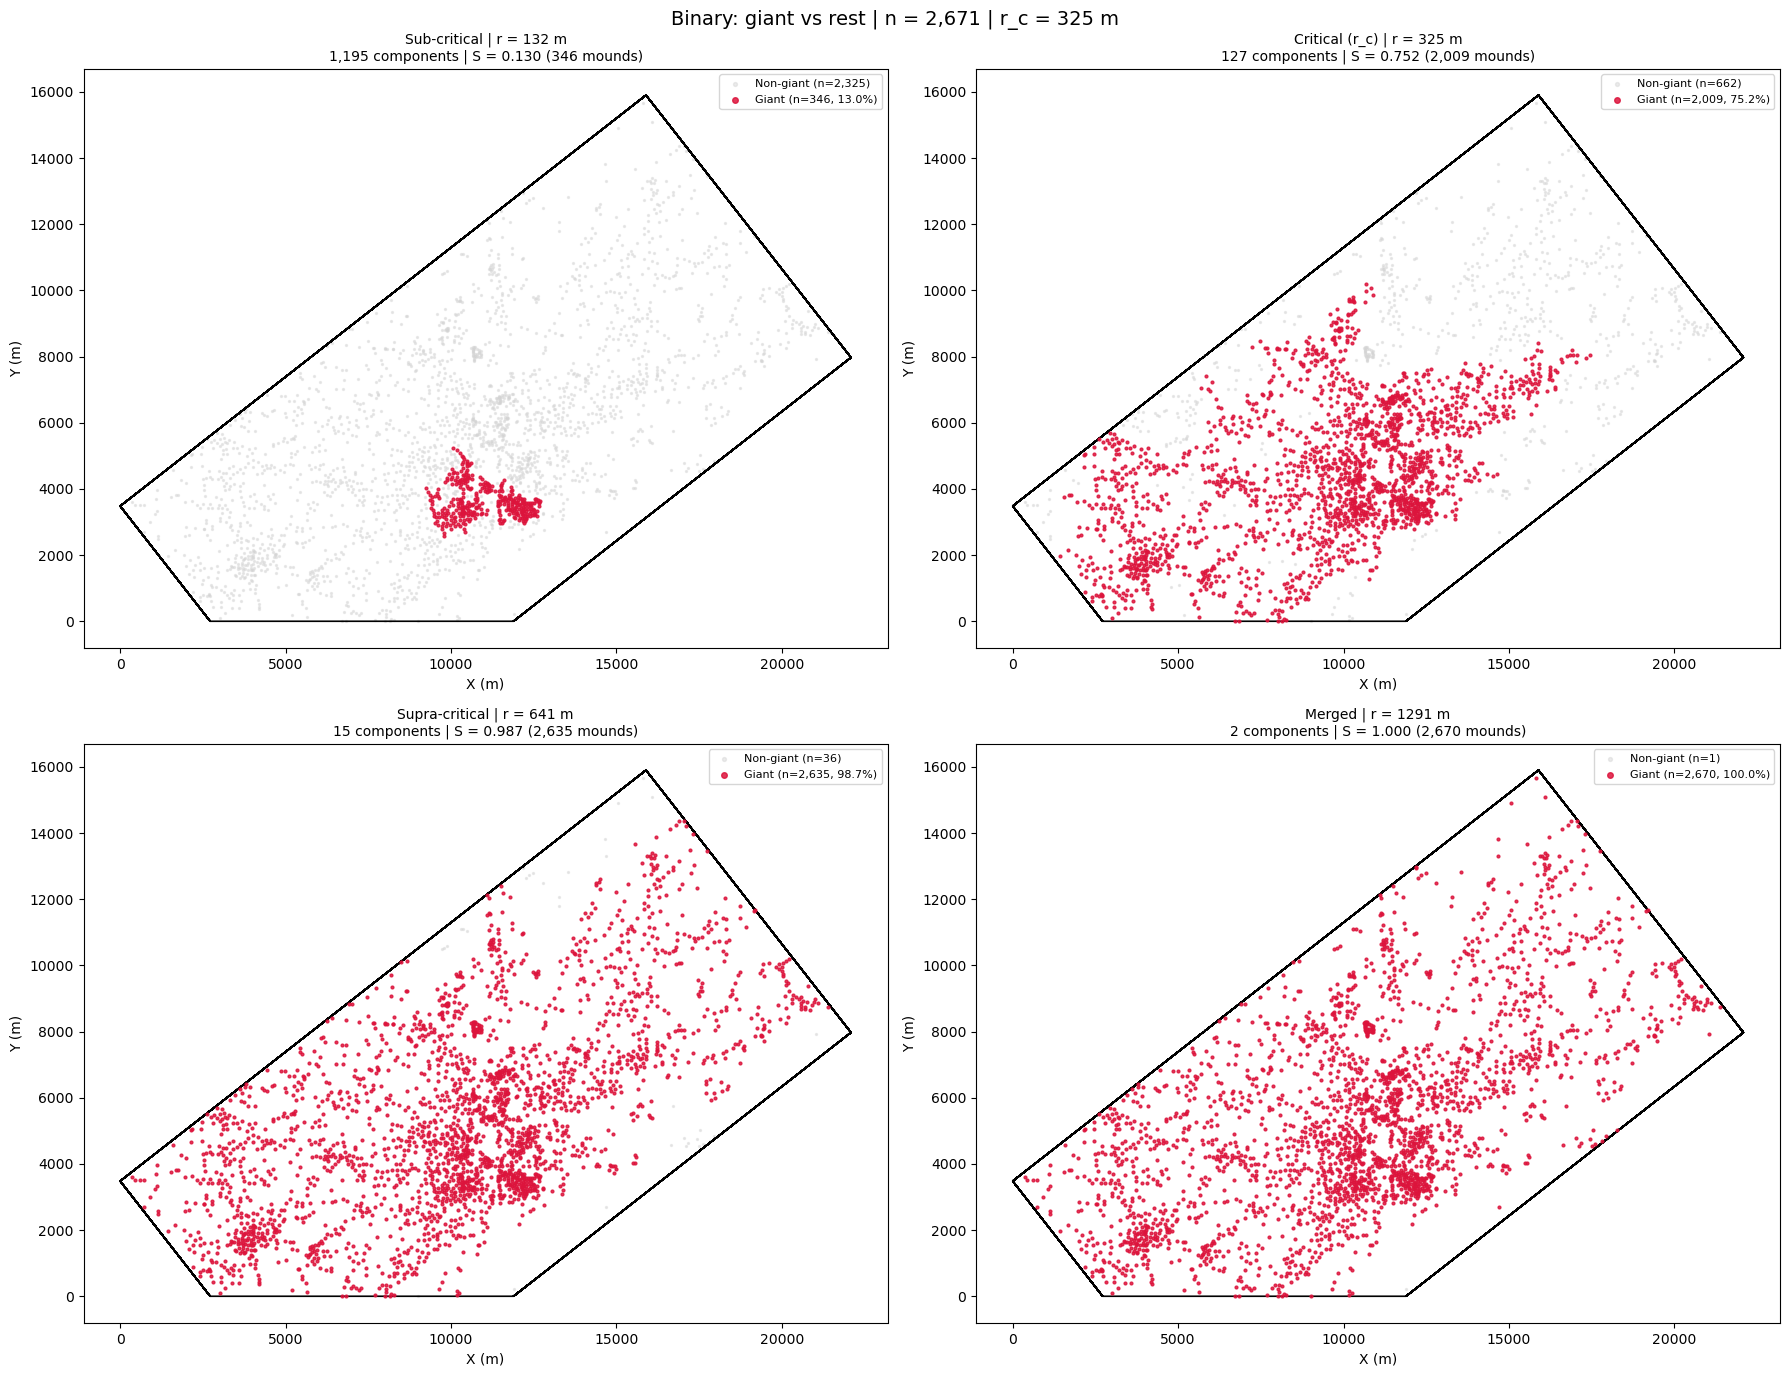

Saved: percolation_multiscale_binary.png


In [22]:
# Binary (giant vs rest) ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, r, lbl in zip(axes.ravel(), r_compare, labels_compare):
    comps_r = all_comps[r]
    giant_r = np.array(list(comps_r[0]))
    other_r = np.array([n for c in comps_r[1:] for n in c])
    S_r     = len(giant_r) / N

    if len(other_r) > 0:
        ax.scatter(coords[other_r, 0], coords[other_r, 1],
                   s=2, c='lightgrey', alpha=0.45, zorder=2,
                   label=f'Non-giant (n={len(other_r):,})')
    ax.scatter(coords[giant_r, 0], coords[giant_r, 1],
               s=4, c='crimson', alpha=0.85, zorder=3,
               label=f'Giant (n={len(giant_r):,}, {100*len(giant_r)/N:.1f}%)')
    parcel.boundary.plot(ax=ax, color='black', linewidth=1.2)
    ax.set_title(
        f'{lbl} | r = {r:.0f} m\n'
        f'{len(comps_r):,} components | S = {S_r:.3f} ({len(giant_r):,} mounds)',
        fontsize=10
    )
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=8, markerscale=2)

fig.suptitle(
    f'Binary: giant vs rest | n = {N:,} | r_c = {rc_deriv:.0f} m',
    fontsize=14
)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/percolation_multiscale_binary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: percolation_multiscale_binary.png')

In [24]:
# Coalescence map ---
# For each mound, record the first r_compare threshold at which it joins the giant component.
# Mounds that never join within the sweep are labelled -1 (grey).

join_stage = np.full(N, -1, dtype=int)  # -1 = never joins within sweep

for stage, r in enumerate(r_compare):
    giant_nodes = np.array(list(all_comps[r][0]))
    # Only update mounds that haven't been assigned a stage yet
    new_joiners = giant_nodes[join_stage[giant_nodes] == -1]
    join_stage[new_joiners] = stage

stage_labels = [
    f'Stage 1 - sub-critical (r = {r_compare[0]:.0f} m)',
    f'Stage 2 - critical r_c (r = {r_compare[1]:.0f} m)',
    f'Stage 3 - supra-critical (r = {r_compare[2]:.0f} m)',
    f'Stage 4 - merged (r = {r_compare[3]:.0f} m)',
]
stage_colors = ['#2166ac', '#4dac26', '#f4a582', '#d6604d']  # blue, green, light-red, dark-red
never_mask   = join_stage == -1

print('Mounds per stage:')
for s, lbl in enumerate(stage_labels):
    n_s = (join_stage == s).sum()
    print(f'  {lbl}: {n_s:,} ({100*n_s/N:.1f}%)')
print(f'  Never joins giant: {never_mask.sum():,} ({100*never_mask.sum()/N:.1f}%)')

Mounds per stage:
  Stage 1 - sub-critical (r = 132 m): 346 (13.0%)
  Stage 2 - critical r_c (r = 325 m): 1,663 (62.3%)
  Stage 3 - supra-critical (r = 641 m): 626 (23.4%)
  Stage 4 - merged (r = 1291 m): 35 (1.3%)
  Never joins giant: 1 (0.0%)


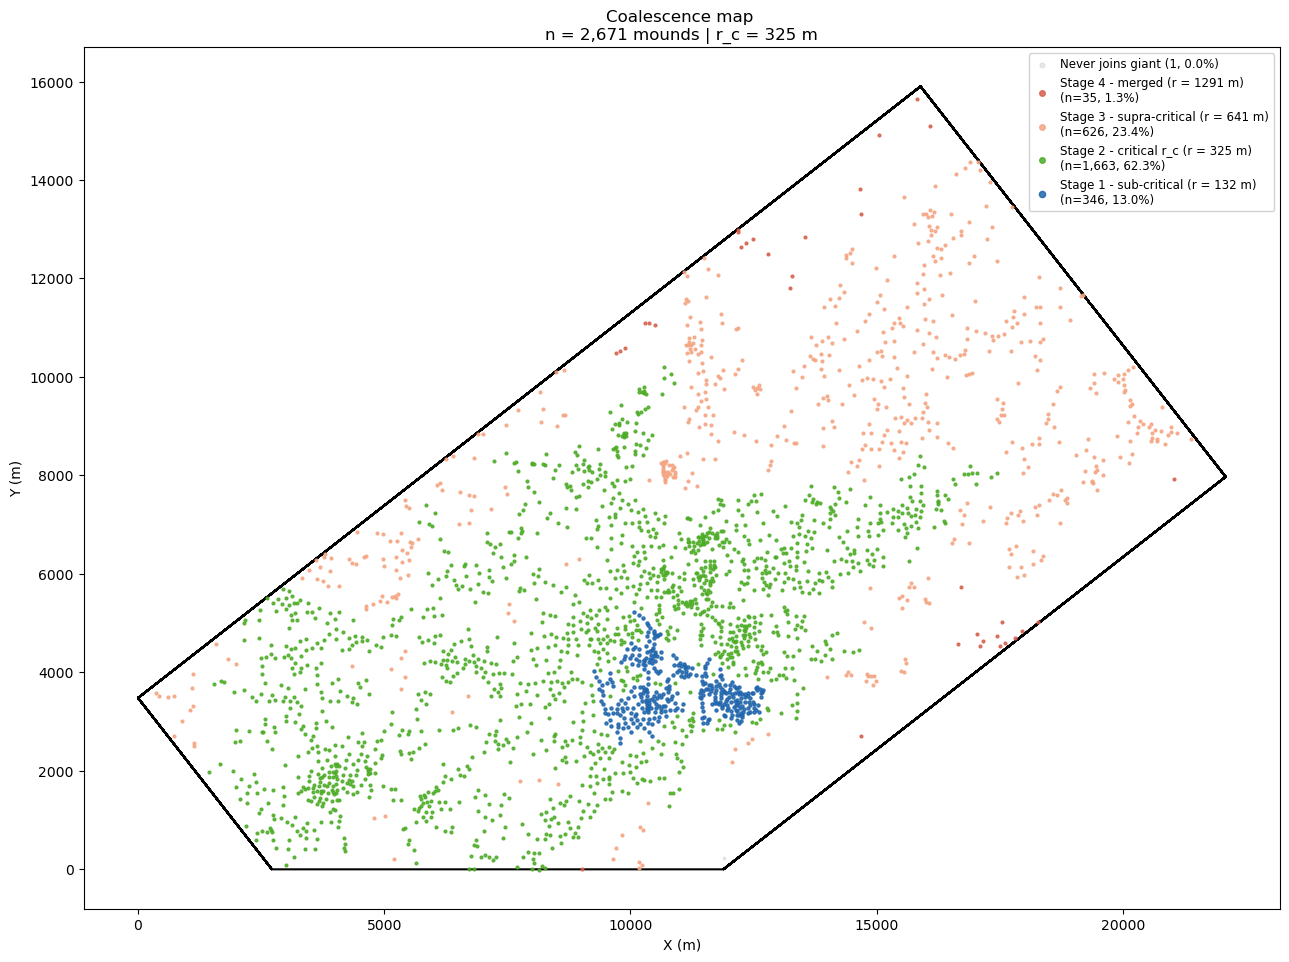

Saved: percolation_coalescence_map.png


In [26]:
fig, ax = plt.subplots(figsize=(13, 10))

# Grey: never joins
if never_mask.sum() > 0:
    ax.scatter(coords[never_mask, 0], coords[never_mask, 1],
               s=3, c='lightgrey', alpha=0.5, zorder=2,
               label=f'Never joins giant ({never_mask.sum():,}, {100*never_mask.sum()/N:.1f}%)')

# Stages 4 --> 1 so earliest joiners sit on top
for s in range(len(stage_labels) - 1, -1, -1):
    mask_s = join_stage == s
    if mask_s.sum() == 0:
        continue
    ax.scatter(coords[mask_s, 0], coords[mask_s, 1],
               s=5 if s == 0 else 4,
               c=stage_colors[s], alpha=0.85,
               zorder=3 + (len(stage_labels) - s),
               label=f'{stage_labels[s]}\n(n={mask_s.sum():,}, {100*mask_s.sum()/N:.1f}%)')

parcel.boundary.plot(ax=ax, color='black', linewidth=1.5)
ax.set_title(
    f'Coalescence map \n'
    f'n = {N:,} mounds | r_c = {rc_deriv:.0f} m',
    fontsize=12
)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8.5, markerscale=2,
          framealpha=0.85, handlelength=1.5)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/percolation_coalescence_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: percolation_coalescence_map.png')

## 9. Component size histogram

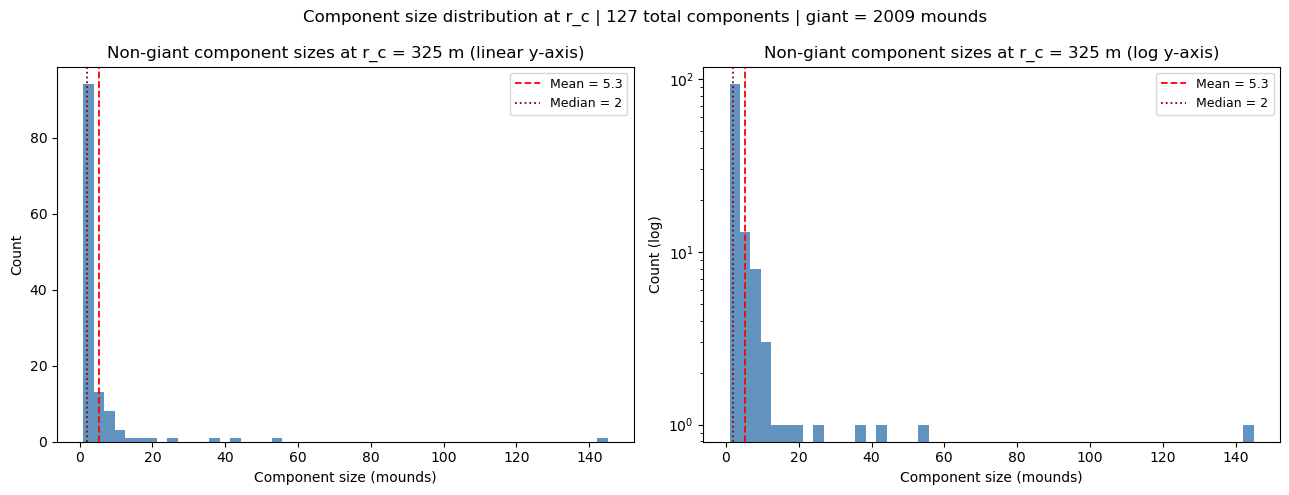

In [27]:
comps_rc_all, _ = get_components_at_r(rc_deriv)
sizes_rc = np.array([len(c) for c in comps_rc_all])
sizes_non_giant = sizes_rc[sizes_rc < sizes_rc.max()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    ax.hist(sizes_non_giant, bins=50, color='steelblue', alpha=0.85, edgecolor='none')
    ax.axvline(sizes_non_giant.mean(), color='red', linestyle='--', linewidth=1.3,
               label=f'Mean = {sizes_non_giant.mean():.1f}')
    ax.axvline(np.median(sizes_non_giant), color='darkred', linestyle=':', linewidth=1.3,
               label=f'Median = {np.median(sizes_non_giant):.0f}')
    ax.set_yscale(yscale)
    ax.set_xlabel('Component size (mounds)')
    ax.set_ylabel('Count' if yscale == 'linear' else 'Count (log)')
    ax.set_title(f'Non-giant component sizes at r_c = {rc_deriv:.0f} m ({yscale} y-axis)')
    ax.legend(fontsize=9)

fig.suptitle(
    f'Component size distribution at r_c | {len(comps_rc_all):,} total components | giant = {sizes_rc.max()} mounds',
    fontsize=12
)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/percolation_comp_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Edge density map at r_c

Each mound is coloured by its degree (number of neighbours within r_c). High-degree nodes are dense local hubs; low-degree nodes are peripheral. Isolates (degree 0) appear in grey.

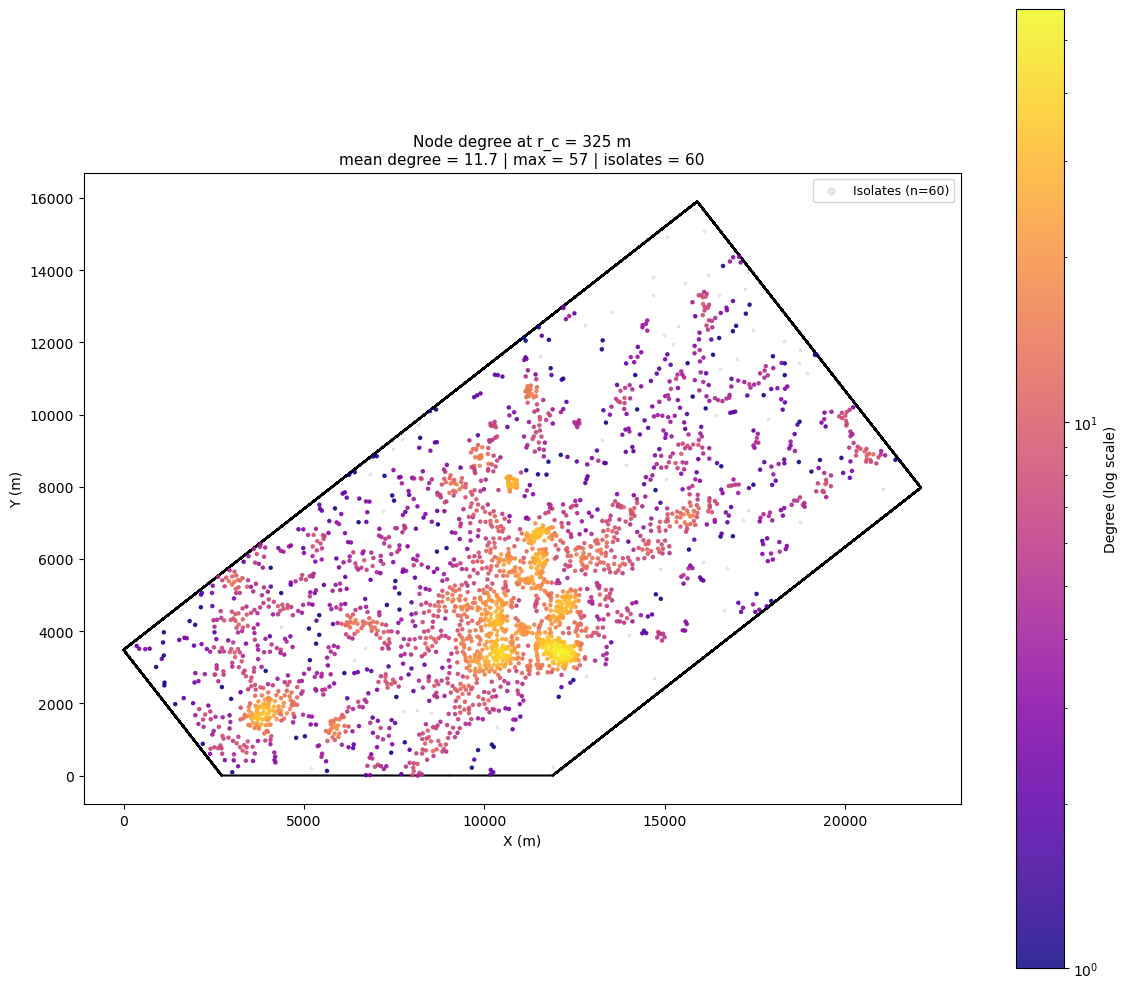

In [28]:
degrees_rc = np.array([G_rc.degree(i) for i in range(N)])
isolates_mask  = degrees_rc == 0
connected_mask = ~isolates_mask

fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(coords[isolates_mask, 0], coords[isolates_mask, 1],
           s=3, c='lightgrey', alpha=0.5, zorder=2,
           label=f'Isolates (n={isolates_mask.sum():,})')

sc = ax.scatter(coords[connected_mask, 0], coords[connected_mask, 1],
                s=5, c=degrees_rc[connected_mask], cmap='plasma',
                norm=mcolors.LogNorm(vmin=1, vmax=degrees_rc.max()),
                alpha=0.85, zorder=3)

plt.colorbar(sc, ax=ax, label='Degree (log scale)')
parcel.boundary.plot(ax=ax, color='black', linewidth=1.5)
ax.set_title(
    f'Node degree at r_c = {rc_deriv:.0f} m\n'
    f'mean degree = {degrees_rc[connected_mask].mean():.1f} | max = {degrees_rc.max()} | isolates = {isolates_mask.sum():,}',
    fontsize=11
)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9, markerscale=3)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/percolation_degree_map.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Summary statistics

In [29]:
comps_below, _ = get_components_at_r(r_compare[0])
comps_above, _ = get_components_at_r(r_compare[2])

print(f"n mounds:               {N:,}")
print(f"Mean NND:               {mean_nnd:.1f} m")
print()
print(f"r_c (max dS/dr):        {rc_deriv:.1f} m")
print(f"r_c (first spanning):   {rc_span:.1f} m" if not np.isnan(rc_span) else "r_c (first spanning):   not reached in sweep")
print()
print(f"At r_c = {rc_deriv:.0f} m:")
print(f"  Components:           {len(comps_rc):,}")
print(f"  Giant component:      {len(comps_rc[0]):,} mounds ({100*len(comps_rc[0])/N:.1f}%)")
print(f"  Mean degree:          {degrees_rc[connected_mask].mean():.2f}")
print(f"  Isolates:             {isolates_mask.sum():,} ({100*isolates_mask.sum()/N:.1f}%)")
print()
print(f"Sub-critical (r = {r_compare[0]:.0f} m):")
print(f"  Components:           {len(comps_below):,}")
print(f"  Giant component:      {len(comps_below[0]):,} ({100*len(comps_below[0])/N:.1f}%)")
print()
print(f"Supra-critical (r = {r_compare[2]:.0f} m):")
print(f"  Components:           {len(comps_above):,}")
print(f"  Giant component:      {len(comps_above[0]):,} ({100*len(comps_above[0])/N:.1f}%)")

n mounds:               2,671
Mean NND:               120.1 m

r_c (max dS/dr):        325.2 m
r_c (first spanning):   1117.4 m

At r_c = 325 m:
  Components:           127
  Giant component:      2,009 mounds (75.2%)
  Mean degree:          11.72
  Isolates:             60 (2.2%)

Sub-critical (r = 132 m):
  Components:           1,195
  Giant component:      346 (13.0%)

Supra-critical (r = 641 m):
  Components:           15
  Giant component:      2,635 (98.7%)


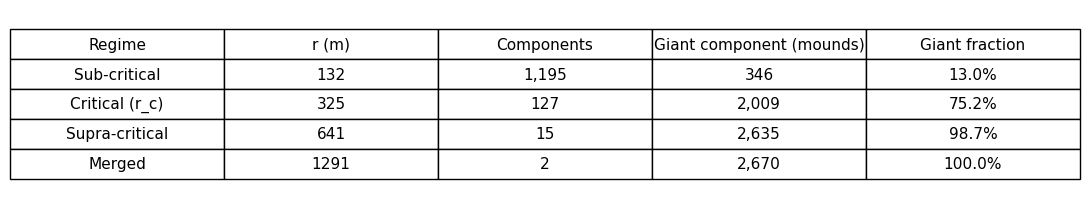

In [30]:
summary_rows = []
for r, lbl in zip(r_compare, labels_compare):
    comps_r, _ = get_components_at_r(r)
    giant_r    = len(comps_r[0])
    summary_rows.append([
        lbl,
        f'{r:.0f}',
        f'{len(comps_r):,}',
        f'{giant_r:,}',
        f'{100*giant_r/N:.1f}%',
    ])

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.axis('off')
table = ax.table(
    cellText=summary_rows,
    colLabels=['Regime', 'r (m)', 'Components', 'Giant component (mounds)', 'Giant fraction'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/percolation_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()